In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

Generating Fake Data using Numpy

In [4]:
np.random.seed(42)
n = 200

strokes = np.random.choice(["forehand", "backhand", "serve"], size = n, p =[.5, .35, .15])
confidence = np.random.uniform(.4, 1, size = n)
timestamps = np.arange(0, n * .5, .5)
wrist_x = np.random.uniform(.3,.7, size = n)
wrist_y = np.random.uniform(.2,.8, size = n)


In [5]:
df = pd.DataFrame({
    "timestamps": timestamps,
    "strokes": strokes,
    "confidence": confidence,
    "wrist_x": wrist_x,
    "wrist_y": wrist_y
})
df.head()

,timestamps,strokes,confidence,wrist_x,wrist_y
0,0.0,forehand,0.785219,0.341250,0.301361
1,0.5,serve,0.450484,0.661021,0.367154
2,1.0,backhand,0.496977,0.502101,0.306206
3,1.5,backhand,0.939133,0.630583,0.253222
4,2.0,forehand,0.763857,0.428020,0.272382


In [10]:
df_filtered = df[df["confidence"] > .7]
print(f"Original: {len(df)} strokes")
print(f"Filtered: {len(df_filtered)} strokes")
print(f"Removed {len(df)- len(df_filtered)} strokes")

Original: 200 strokes
Filtered: 109 strokes
Removed 91 strokes


In [13]:
num_of_strokes = df_filtered.groupby("strokes")["confidence"].count()
print (num_of_strokes)

confi_of_strokes = df_filtered.groupby("strokes")["confidence"].mean()
print (confi_of_strokes)



strokes
backhand    40
forehand    55
serve       14
Name: confidence, dtype: int64
strokes
backhand    0.840759
forehand    0.846083
serve       0.827569
Name: confidence, dtype: float64


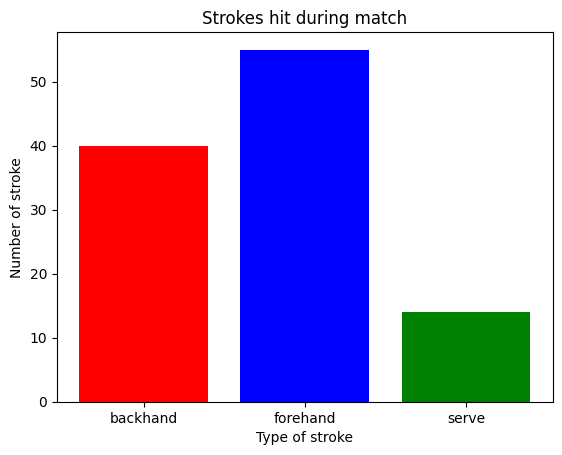

In [19]:
plt.bar(num_of_strokes.index, num_of_strokes.values, color = ["red", "blue", "green"])
plt.title("Strokes hit during match")
plt.xlabel("Type of stroke")
plt.ylabel("Number of stroke")
plt.show()

Text(0, 0.5, 'Count')

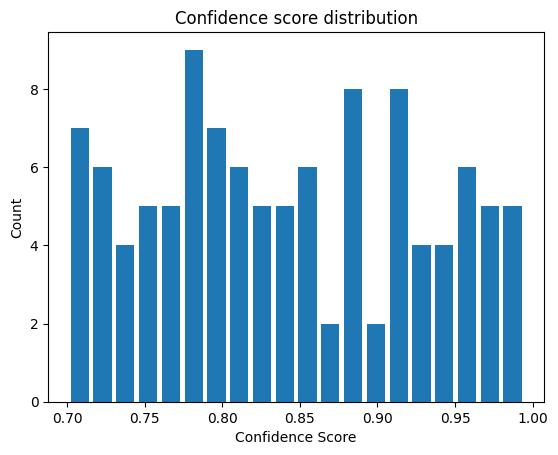

In [26]:
plt.hist(df_filtered["confidence"], bins= 20, rwidth= .8)
plt.title("Confidence score distribution")
plt.xlabel("Confidence Score")
plt.ylabel("Count")


Text(0, 0.5, 'Wrist y pos')

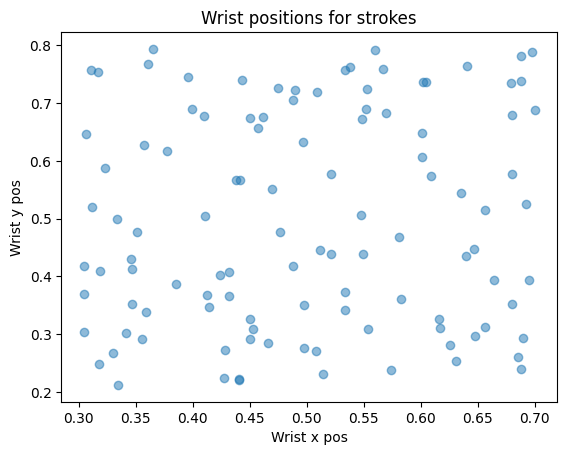

In [27]:
plt.scatter(df_filtered["wrist_x"], df_filtered["wrist_y"], alpha = .5)
plt.title("Wrist positions for strokes")
plt.xlabel("Wrist x pos")
plt.ylabel("Wrist y pos")